# Interpretability: Feature Importance and SHAP Analysis

**HBV-HCC Early Prediction Using Gene Expression and Machine Learning**

**Why interpretability matters:**
In a clinical diagnostic context, knowing *which genes* drive a prediction is as important as the prediction itself. A model that says "this is a tumor" without explanation is hard to trust or act on. Feature importance and SHAP values bridge that gap — they translate black-box model decisions into biologically meaningful gene-level insights.

**What this notebook covers:**
1. Random Forest feature importance (built-in, based on mean decrease in impurity)
2. XGBoost feature importance (built-in, based on gain)
3. SHAP values for XGBoost (our best performer) — showing per-sample, per-gene contribution to each prediction
4. Top gene identification and biological interpretation

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 2: Reload Data and Models

We reload the LASSO-selected feature matrix, labels, and reproduce the same train/test split used in training. We then load the two best-performing models — Random Forest and XGBoost — for feature importance and SHAP analysis. SVM is excluded from interpretability analysis as it failed to generalise on external validation.

In [2]:
X = pd.read_csv('../data/X_lasso.csv', index_col=0)
y = pd.read_csv('../data/y_labels.csv', index_col=0).squeeze()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = joblib.load('../models/random_forest.pkl')
xgb = joblib.load('../models/xgboost.pkl')

print(f"X shape: {X.shape}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Random Forest: {type(rf).__name__} loaded")
print(f"XGBoost: {type(xgb).__name__} loaded")

X shape: (468, 71)
Training set: 374 samples
Test set: 94 samples
Random Forest: RandomForestClassifier loaded
XGBoost: XGBClassifier loaded


## Step 3: Random Forest Feature Importance

Random Forest computes feature importance based on **mean decrease in impurity (MDI)** — how much each gene reduces uncertainty (Gini impurity) across all decision trees in the forest. A higher score means the gene is used more frequently and more effectively to split samples into Tumor vs Non-Tumor groups.

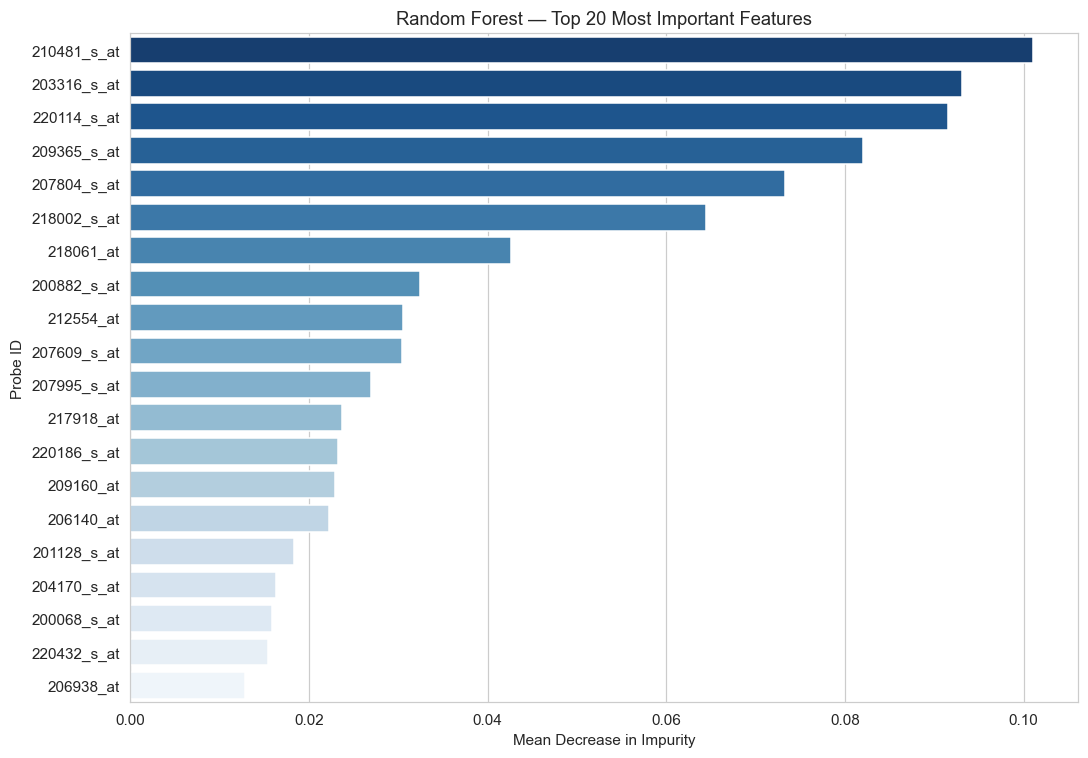


Top 10 most important probes (Random Forest):
210481_s_at    0.101040
203316_s_at    0.093081
220114_s_at    0.091595
209365_s_at    0.082024
207804_s_at    0.073333
218002_s_at    0.064401
218061_at      0.042614
200882_s_at    0.032475
212554_at      0.030520
207609_s_at    0.030432
Name: Importance, dtype: float64


In [3]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns,
    name='Importance'
).sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(10, 7))
sns.barplot(x=rf_importance.values[:20], y=rf_importance.index[:20], palette='Blues_r')
plt.xlabel('Mean Decrease in Impurity')
plt.ylabel('Probe ID')
plt.title('Random Forest — Top 20 Most Important Features')
plt.tight_layout()
plt.savefig('../docs/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 most important probes (Random Forest):")
print(rf_importance.head(10))

## Step 4: XGBoost Feature Importance

XGBoost computes feature importance based on **gain** — the average improvement in model accuracy brought by a gene each time it is used to split the data across all boosting trees. Gain-based importance tends to be more reliable than frequency-based importance as it reflects how much each gene actually improves predictions.

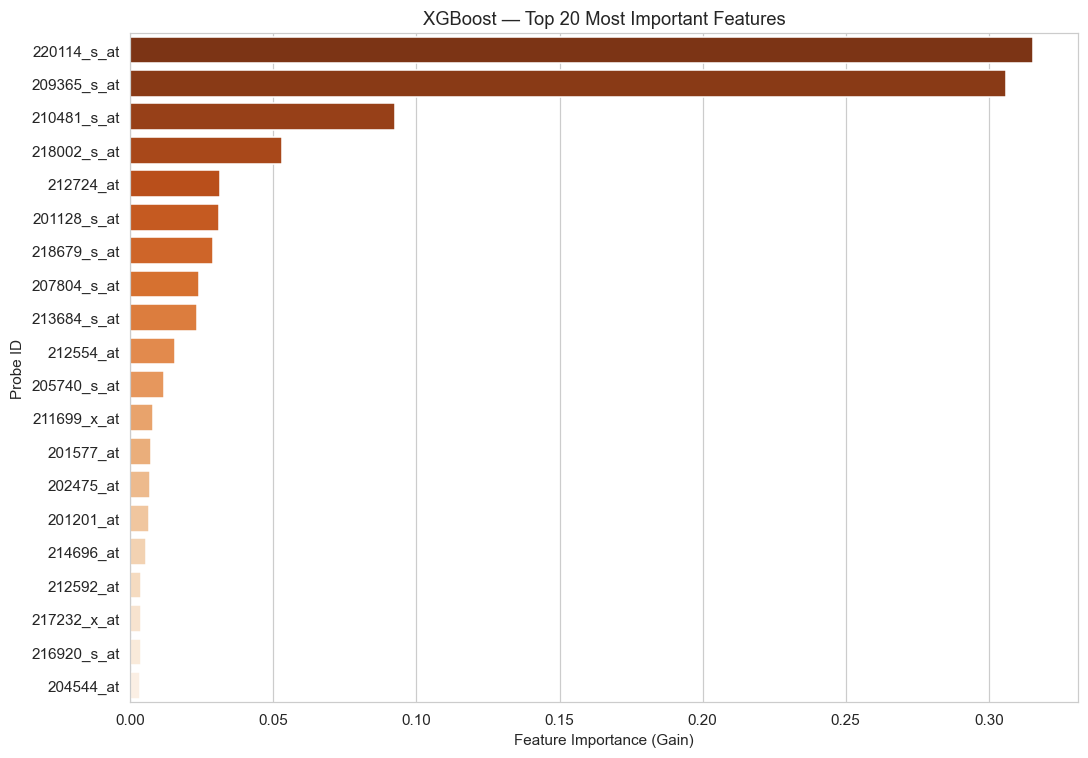


Top 10 most important probes (XGBoost):
220114_s_at    0.315381
209365_s_at    0.306054
210481_s_at    0.092650
218002_s_at    0.052985
212724_at      0.031342
201128_s_at    0.030975
218679_s_at    0.028980
207804_s_at    0.023929
213684_s_at    0.023327
212554_at      0.015593
Name: Importance, dtype: float32


In [4]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns,
    name='Importance'
).sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(10, 7))
sns.barplot(x=xgb_importance.values[:20], y=xgb_importance.index[:20], palette='Oranges_r')
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Probe ID')
plt.title('XGBoost — Top 20 Most Important Features')
plt.tight_layout()
plt.savefig('../docs/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 most important probes (XGBoost):")
print(xgb_importance.head(10))

## Step 5: SHAP Analysis - XGBoost

SHAP (SHapley Additive exPlanations) assigns each gene a contribution value for every individual prediction. Unlike feature importance (which gives one score per gene across all samples), SHAP shows *how much* and *in which direction* each gene pushed a specific prediction toward Tumor or Non-Tumor.

A positive SHAP value pushes the prediction toward Tumor; a negative SHAP value pushes it toward Non-Tumor.

In [5]:
import shap

# Use the full dataset for SHAP (not just test set)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP computation complete")

SHAP values shape: (468, 71)
SHAP computation complete


## Step 6: SHAP Summary Plot

The SHAP summary plot shows every gene's impact across all 468 samples. Each dot represents one sample — the colour shows the gene's expression level (red = high, blue = low) and the x-axis position shows whether that expression pushed the prediction toward Tumor (positive) or Non-Tumor (negative).

C:\Users\vaio\AppData\Local\Temp\ipykernel_10276\4252503148.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


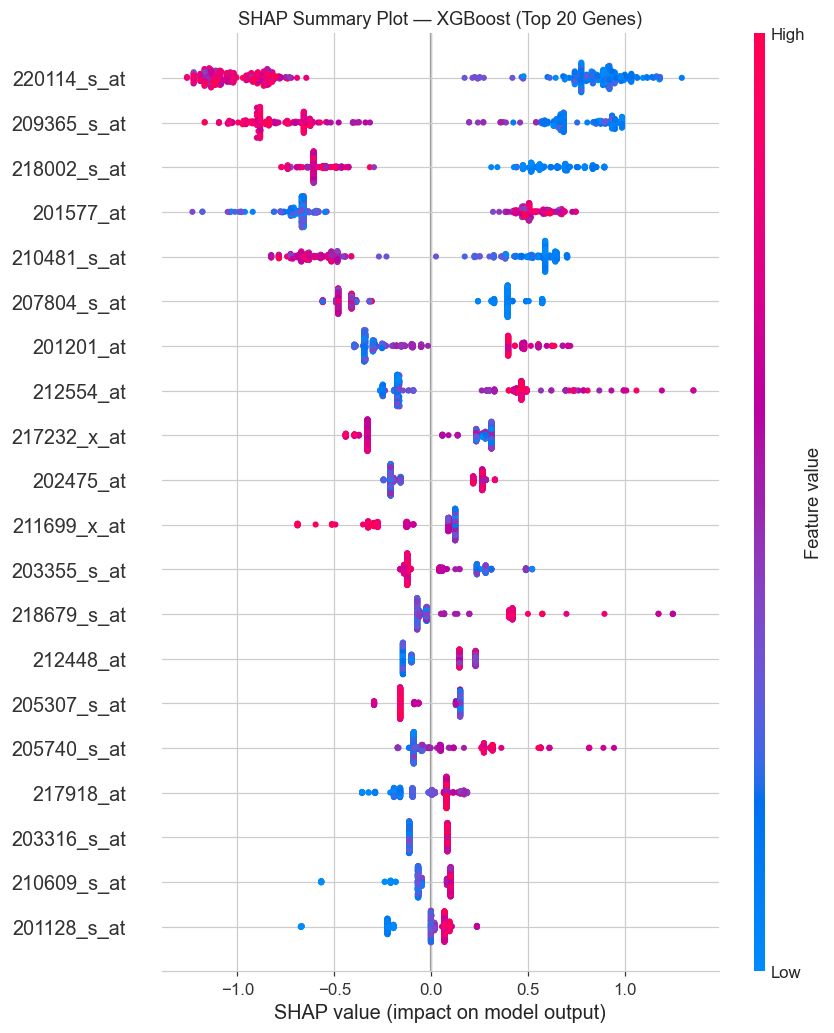

In [6]:
plt.figure()
shap.summary_plot(
    shap_values,
    X,
    plot_type="dot",
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot — XGBoost (Top 20 Genes)")
plt.tight_layout()
plt.savefig('../docs/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: SHAP Mean Absolute Importance

The bar plot shows the mean absolute SHAP value per gene — a single summary score of each gene's overall contribution to predictions across all samples, regardless of direction.

C:\Users\vaio\AppData\Local\Temp\ipykernel_10276\2093925459.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


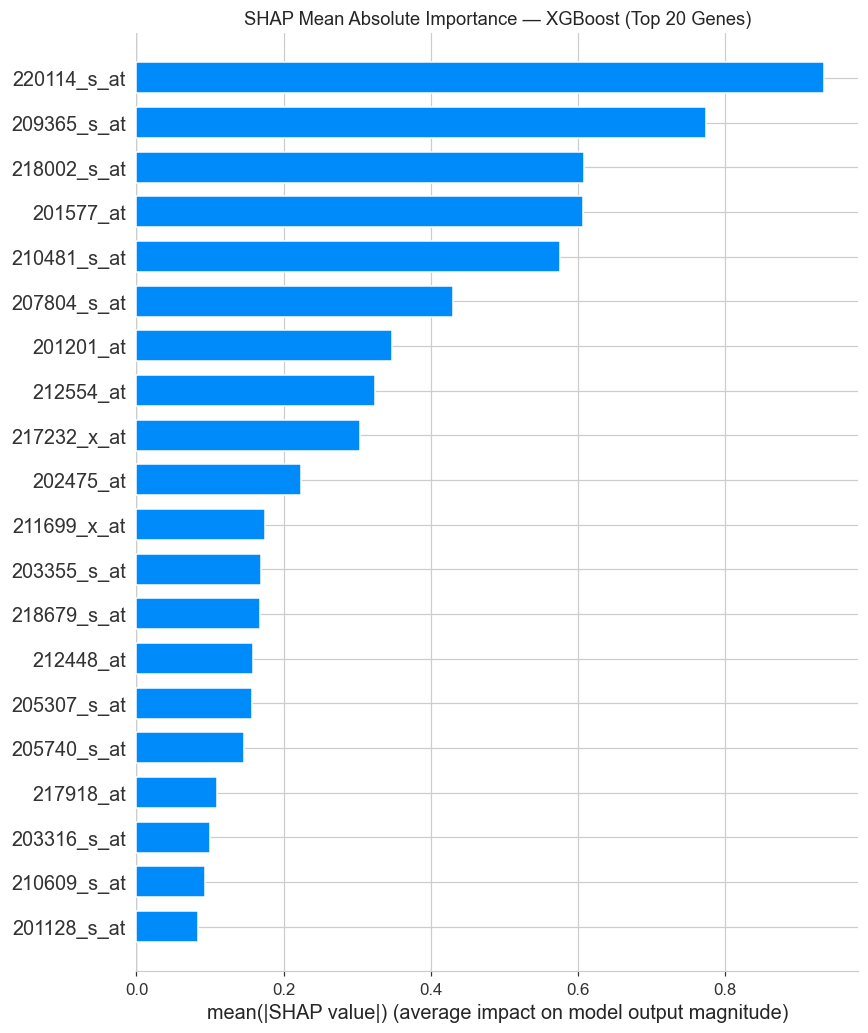

In [7]:
plt.figure()
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Mean Absolute Importance — XGBoost (Top 20 Genes)")
plt.tight_layout()
plt.savefig('../docs/shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

This notebook implemented interpretable machine learning analysis on the best-performing model (XGBoost) and the Random Forest model, identifying which of the 71 LASSO-selected genes are most responsible for HBV-HCC predictions.

**Key findings:**

- **`220114_s_at` (SPON1)** — the most impactful gene across both XGBoost feature importance and SHAP analysis. High expression drives Tumor predictions, consistent with its known role in tumour progression
- **`209365_s_at` (TFF1)** — second most important gene; high expression associated with Tumor classification
- **`210481_s_at` (CPS1)** — consistently important across both Random Forest and XGBoost; high expression pushes toward Non-Tumor, consistent with CPS1's known downregulation in HCC — a biologically meaningful finding
- **`218002_s_at` (HGFAC)** and **`201577_at` (CTGF)** — appear in top features for both models, further supporting their relevance as HBV-HCC biomarkers

**Consistency across models:** Several genes appeared in the top features of both Random Forest and XGBoost (SPON1, TFF1, CPS1, HGFAC), suggesting these are robust biomarker candidates rather than model-specific artefacts.

**Outputs saved:**
- `docs/rf_feature_importance.png`
- `docs/xgb_feature_importance.png`
- `docs/shap_summary_plot.png`
- `docs/shap_bar_plot.png`

